### **RNA-seq Data Analysis**

**<span style="color: darkred;">This notebook includes RNA-seq analysis.</span>**

RNA-seq data can be found in:

_/scratch/prj/stem_cells_pituitary/Georgia/RNAseq_data/raw_data/_

Files include:
- median_RNAexpression_per_celltype.csv: Adult mm10 cohort
- trajectory_annotated_rna.h5ad: Neonatal mm10 cohort

In [2]:
# Libraries
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d
import pandas as pd
#pip install decoupler==1.8.0
import decoupler as dc
from scipy import stats
from statsmodels.stats.multitest import multipletests
from scipy.stats import f_oneway

/scratch/users/k25055720/conda_envs/scprint/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### **Initial processing -> UMAP**

In [3]:
# Load RNA Trajectory Data in 
adata = sc.read("/scratch/prj/stem_cells_pituitary/Georgia/RNAseq_data/raw_data/trajectory_annotated_rna.h5ad")

In [4]:
# Norm and Log1p
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

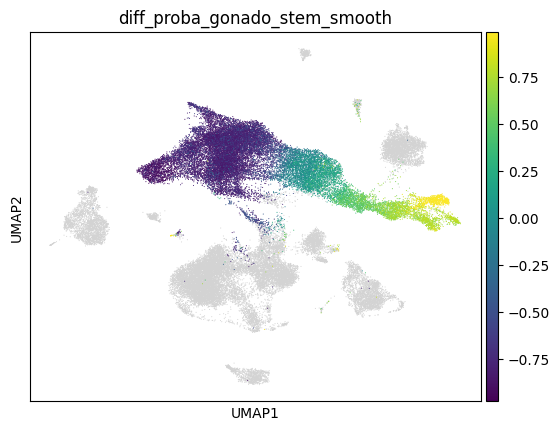

In [5]:
# Plot UMAP
sc.pl.umap(adata,color='diff_proba_gonado_stem_smooth')

In [6]:
print(adata.obs.columns)

Index(['0', 'n_genes', 'n_counts', 'n_genes_by_counts',
       'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts',
       'pct_counts_in_top_20_genes', 'total_counts_mt',
       'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo',
       'log1p_total_counts_ribo', 'pct_counts_ribo', 'doublet_score',
       'predicted_doublet', 'size_factor', 'assignments',
       'predicted_cell_type', 'predicted_cell_type_proba',
       'proba_Corticotrophs', 'proba_Endothelial_cells', 'proba_Erythrocytes',
       'proba_Gonadotrophs', 'proba_Immune_cells', 'proba_Lactotrophs',
       'proba_Melanotrophs', 'proba_Mesenchymal_cells', 'proba_Pituicytes',
       'proba_Somatotrophs', 'proba_Stem_cells', 'proba_Thyrotrophs',
       'cell_type_final', 'pct_counts_kept', 'init_predicted_doublet_epitome',
       'thresholded_doublet_epitome', 'doublet_score_epitome', 'new_cell_type',
       'SRA_ID', 'total_counts_malat', 'log1p_total_counts_malat',
       'pct_counts_malat', 'batch', 

In [7]:
print(adata.obs['cell_type_final'].unique())

['Somatotrophs', 'Stem_cells', 'Pituicytes', 'Gonadotrophs', 'Mesenchymal_cells', ..., 'Thyrotrophs', 'Immune_cells', 'Endothelial_cells', 'Lactotrophs', 'Erythrocytes']
Length: 12
Categories (12, object): ['Corticotrophs', 'Endothelial_cells', 'Erythrocytes', 'Gonadotrophs', ..., 'Pituicytes', 'Somatotrophs', 'Stem_cells', 'Thyrotrophs']


#### **Gonadotroph Trajectory Processing**

In [ ]:
gonadotroph_trajectory_object = adata[adata.obs["diff_proba_gonado_stem_smooth"].notna()]
gonadotroph_trajectory_object

In [9]:
# For ease of interpretation, min max normalise it between 0-1
v = gonadotroph_trajectory_object.obs["diff_proba_gonado_stem_smooth"].astype(float)
gonadotroph_trajectory_object.obs["diff_proba_gonado_stem_smooth"] = (v - v.min()) / (v.max() - v.min())

/tmp/ipykernel_2821249/1273523535.py:3: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  gonadotroph_trajectory_object.obs["diff_proba_gonado_stem_smooth"] = (v - v.min()) / (v.max() - v.min())


In [10]:
# Where is the trajectory stored
adata.obs['trajectory_gonado'].value_counts()

trajectory_gonado
0.0    3154
6.0    1074
1.0     719
5.0     579
4.0     327
2.0     290
3.0     199
Name: count, dtype: int64

In [11]:

matches = [g for g in adata.var_names if g.lower() == 'tead2']
print(matches)

['Tead2']


#### **Plot Gene Expression Data**

In [12]:
def trajectory_strip(adata, gene, traj_col, layer=None, window=100,
                     cmap='viridis', figsize=(12, 1.6), ax=None):
    sub = adata[adata.obs[traj_col].notna()]
    t = sub.obs[traj_col].astype(float).values
    order = np.argsort(t)

    if layer is not None:
        x = sub[:, gene].layers[layer]
    else:
        x = sub[:, gene].X
    x = np.asarray(x.todense()).ravel() if hasattr(x, 'todense') else np.asarray(x).ravel()

    x = x[order]
    t_sorted = t[order]
    w = window
    x_smooth = uniform_filter1d(x, size=w, mode='nearest')

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    im = ax.imshow(x_smooth[None, :], aspect='auto', cmap=cmap,
                   extent=[t_sorted.min(), t_sorted.max(), 0, 1])
    ax.set_yticks([])
    ax.set_xlabel(traj_col)
    ax.set_title(gene)
    fig.colorbar(im, ax=ax, fraction=0.025, pad=0.01, label=f'{gene} expr (smoothed)')
    return fig, ax

(<Figure size 1200x160 with 2 Axes>,
 <Axes: title={'center': 'Lhb'}, xlabel='diff_proba_gonado_stem_smooth'>)

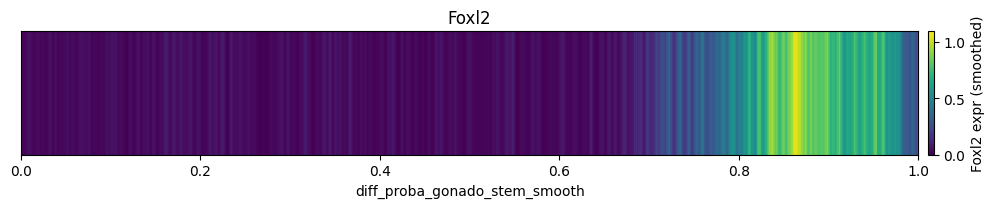

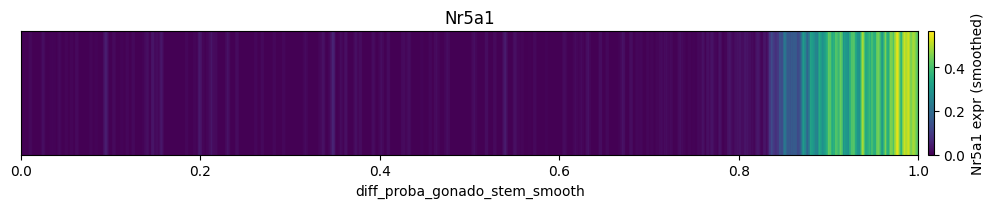

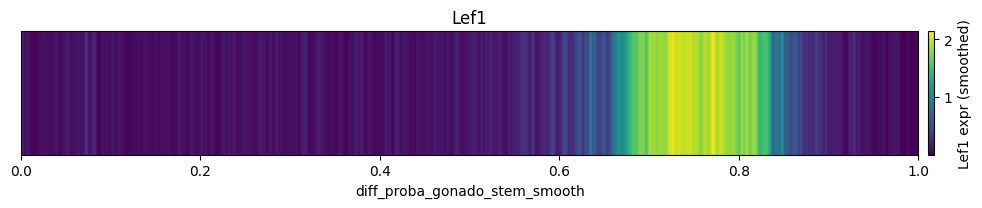

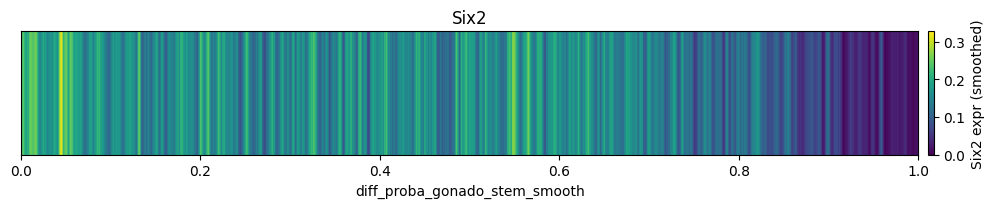

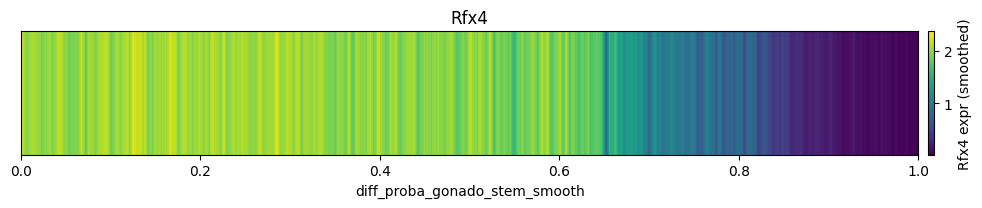

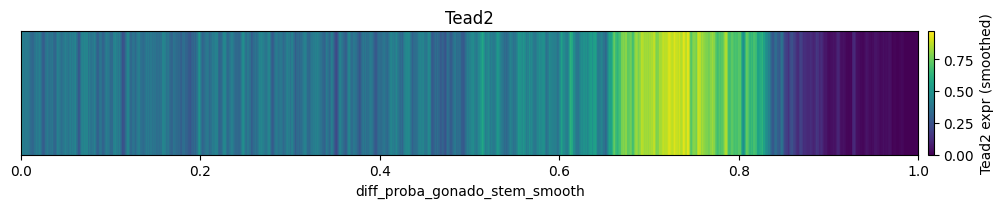

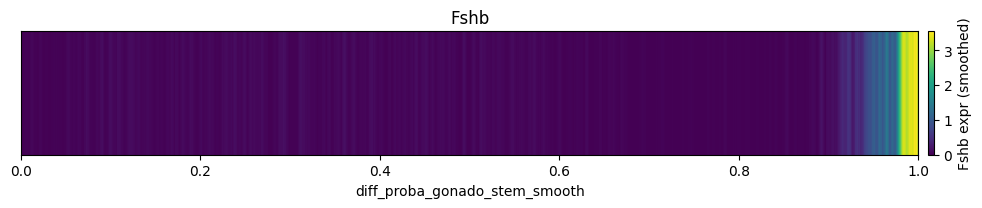

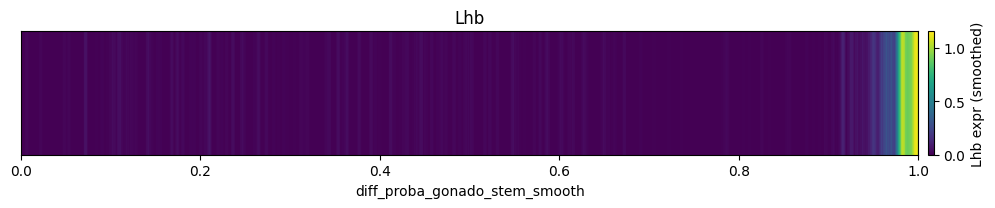

In [34]:
trajectory_strip(gonadotroph_trajectory_object, 'Foxl2', 'diff_proba_gonado_stem_smooth')
trajectory_strip(gonadotroph_trajectory_object, 'Nr5a1', 'diff_proba_gonado_stem_smooth')
trajectory_strip(gonadotroph_trajectory_object, 'Lef1', 'diff_proba_gonado_stem_smooth')
trajectory_strip(gonadotroph_trajectory_object, 'Six2', 'diff_proba_gonado_stem_smooth')
trajectory_strip(gonadotroph_trajectory_object, 'Rfx4', 'diff_proba_gonado_stem_smooth')
trajectory_strip(gonadotroph_trajectory_object, 'Tead2', 'diff_proba_gonado_stem_smooth')
# Hormones secreted
trajectory_strip(gonadotroph_trajectory_object, 'Fshb', 'diff_proba_gonado_stem_smooth')
trajectory_strip(gonadotroph_trajectory_object, 'Lhb', 'diff_proba_gonado_stem_smooth')

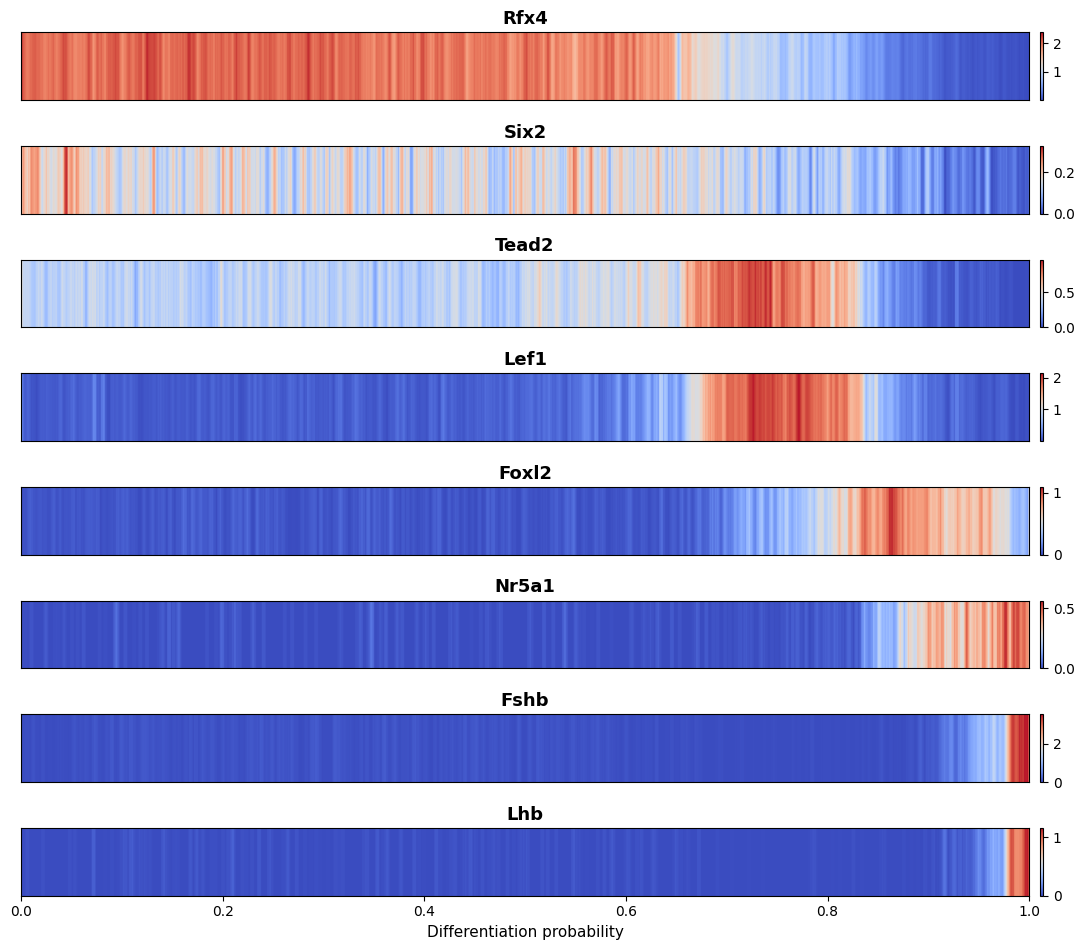

In [32]:
def trajectory_strip(adata, gene, traj_col, bin_col='trajectory_gonado', layer=None, window=100,
                     cmap='coolwarm', figsize=(12, 1.6), ax=None, show_xaxis=True):
    sub = adata[adata.obs[traj_col].notna()]
    t = sub.obs[traj_col].astype(float).values
    order = np.argsort(t)

    if layer is not None:
        x = sub[:, gene].layers[layer]
    else:
        x = sub[:, gene].X
    x = np.asarray(x.todense()).ravel() if hasattr(x, 'todense') else np.asarray(x).ravel()

    x = x[order]
    t_sorted = t[order]
    x_smooth = uniform_filter1d(x, size=window, mode='nearest')

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    im = ax.imshow(x_smooth[None, :], aspect='auto', cmap=cmap,
                   extent=[t_sorted.min(), t_sorted.max(), 0, 1])

    bin_labels = sorted(sub.obs[bin_col].dropna().unique().astype(int))
    bin_positions = [
        sub[sub.obs[bin_col] == b].obs[traj_col].astype(float).mean()
        for b in bin_labels
    ]

    if show_xaxis:
        ax.set_xlabel('Differentiation probability', fontsize=11)
    else:
        ax.set_xticks([])

    ax.set_yticks([])
    ax.set_title(gene, fontsize=13, fontweight='bold')
    fig.colorbar(im, ax=ax, fraction=0.025, pad=0.01)
    return fig, ax


genes = ['Rfx4', 'Six2', 'Tead2', 'Lef1', 'Foxl2', 'Nr5a1', 'Fshb', 'Lhb']

fig, axes = plt.subplots(len(genes), 1, figsize=(11, 1.2 * len(genes)))
for i, (ax, gene) in enumerate(zip(axes, genes)):
    trajectory_strip(gonadotroph_trajectory_object, gene,
                     'diff_proba_gonado_stem_smooth',
                     ax=ax, show_xaxis=(i == len(genes) - 1))

plt.tight_layout()
#plt.savefig('/scratch/prj/stem_cells_pituitary/Georgia/RNAseq_data/Traj_TF_expr.svg', bbox_inches='tight', format='svg', dpi=300)
plt.show()

In [ ]:
genes = ['Tgif1', 'Erf', 'Sox4', 'Zeb2', 'Foxp4', 'Klf2', 'Mafb', 'Dmrta1', 'Klf11', 'Maff', 'Mybl1']

fig, axes = plt.subplots(len(genes), 1, figsize=(11, 1.2 * len(genes)))
for i, (ax, gene) in enumerate(zip(axes, genes)):
    trajectory_strip(gonadotroph_trajectory_object, gene,
                     'diff_proba_gonado_stem_smooth',
                     ax=ax, show_xaxis=(i == len(genes) - 1))

plt.tight_layout()
#plt.savefig('/scratch/prj/stem_cells_pituitary/Georgia/RNAseq_data/Traj_TF_expr.svg', bbox_inches='tight', format='svg', dpi=300)
plt.show()

In [13]:
def trajectory_strip_vertical(adata, gene, traj_col, bin_col='trajectory_gonado', layer=None, window=100,
                              cmap='coolwarm', ax=None, show_yaxis=True):
    sub = adata[adata.obs[traj_col].notna()]
    t = sub.obs[traj_col].astype(float).values
    order = np.argsort(t)

    if layer is not None:
        x = sub[:, gene].layers[layer]
    else:
        x = sub[:, gene].X
    x = np.asarray(x.todense()).ravel() if hasattr(x, 'todense') else np.asarray(x).ravel()

    x = x[order]
    t_sorted = t[order]
    x_smooth = uniform_filter1d(x, size=window, mode='nearest')

    vmin, vmax = x_smooth.min(), x_smooth.max()
    im = ax.imshow(x_smooth[:, None], aspect='auto', cmap=cmap,
                   extent=[0, 1, t_sorted.max(), t_sorted.min()],
                   vmin=vmin, vmax=vmax)

    ax.set_xticks([])
    ax.set_title(gene, fontsize=11, fontweight='bold')

    if show_yaxis:
        ax.set_ylabel('Differentiation probability', fontsize=11)
    else:
        ax.set_yticks([])

    fig = ax.figure
    cbar = fig.colorbar(im, ax=ax, orientation='horizontal', fraction=0.08, pad=0.04)
    
    cbar.ax.tick_params(labelsize=9)

#genes = ['Rfx4', 'Six2', 'Tead2', 'Lef1', 'Foxl2', 'Nr5a1', 'Fshb', 'Lhb']

# Create a grid layout with 1 row and 8 parallel columns
#fig, axes = plt.subplots(1, len(genes), figsize=(1.5 * len(genes), 9))

#for i, (ax, gene) in enumerate(zip(axes, genes)):
#    trajectory_strip_vertical(gonadotroph_trajectory_object, gene,
#                              'diff_proba_gonado_stem_smooth',
#                              ax=ax, show_yaxis=(i == 0))

#plt.tight_layout()
#plt.savefig('/scratch/prj/stem_cells_pituitary/Georgia/RNAseq_data/Traj_TF_expr_vertical.svg', bbox_inches='tight', format='svg', dpi=300)
#plt.show()

In [25]:
# For plotting genes that meet a pseudotime trajectory threshold
# Threshold distance > 25

# Ordered by pseudotime distance
genes_ordered_pseudotime = ['NR2F6', 'SOX8', 'STAT1', 'Nr2f6', 'TCF7L1', 'TBX20', 'FOXM1', 
                 'ELF3', 'ETV1', 'KLF10', 'IKZF1', 'FOXC1', 'Stat6', 'Nr2F6', 
                 'CEBPB', 'SOX2', 'SOX9', 'GRHL1', 'MEF2C', 'RARG', 'HEY1', 
                 'NFIA', 'Ppara', 'BNC2', 'GRHL2', 'Sox6', 'Six3', 'LMX1B', 
                 'REST', 'RARB', 'HEY2', 'E2F1', 'E2F7', 'NFIL3', 'SIX2', 'Ebf4', 
                 'KLF5', 'Npas2', 'TCF7', 'BCL6', 'KLF15', 'TGIF2', 'TEAD3', 'Nr1H4', 
                 'SMAD3', 'DMRTA1', 'ZEB2', 'TGIF1', 'ZBTB40', 'Mafb', 'FOXP4', 'SOX4', 
                 'ZBTB18', 'E2F2', 'TEAD4', 'TEAD2', 'Isl1', 'TBX3', 'MYB', 'Runx1', 
                 'Lef1', 'PROX1', 'EBF1', 'NEUROD1', 'MYT1', 'EHF', 'FOXO6', 'ZEB1', 
                 'SCRT1', 'Foxl2', 'Stat2', 'ELF4', 'Pgr', 'MYT1L', 'ESR1', 'Nr5a1', 
                 'Npas4', 'Twist2', 'GATA2', 'Stat5a', 'RORB', 'PGR', 'Rarg', 'Rarb', 
                 'NR2F1', 'NACC2', 'MEIS2', 'JDP2', 'NFIX']

#genes_ordered_pseudotime = ['PROX1', 'KLF5', 'Twist2', 'Npas2', 'CEBPB', 'ELF4', 'Isl1', 'Ebf4', 'SIX2', 'JDP2', 'EBF1', 'MYT1L', 'RORB', 'BCL6', 'Lef1', 'Stat2', 'MYB', 'TCF7', 'LMX1B', 'TCF7L1', 'Mafb', 'SCRT1', 'TEAD4', 'TEAD3', 'TEAD2', 'Stat6', 'NFIL3', 'E2F7', 'PGR', 'IKZF1', 'Npas4', 'TBX20', 'NEUROD1', 'NFIX', 'NFIA', 'TGIF2', 'TGIF1', 'HEY1', 'MYT1', 'GRHL2', 'KLF15', 'STAT1', 'FOXC1', 'HEY2', 'Stat5a', 'MEIS2', 'BNC2', 'ZBTB40', 'SOX4', 'NACC2', 'E2F2', 'ZEB1', 'E2F1', 'Sox6', 'ZEB2', 'GATA2', 'REST', 'ELF3', 'Six3', 'NR2F6', 'KLF10', 'RARG', 'Ppara', 'ESR1', 'Rarg', 'Nr5a1', 'Foxl2', 'Nr1H4', 'RARB', 'Rarb', 'NR2F1', 'ZBTB18', 'MEF2C', 'EHF', 'SOX9', 'Nr2f6', 'FOXO6', 'FOXP4', 'Runx1', 'FOXM1', 'ETV1', 'SOX2', 'DMRTA1', 'Pgr', 'Nr2F6', 'SMAD3', 'TBX3', 'GRHL1', 'SOX8']

#genes_ordered_temp = ['NR2F6', 'SOX8', 'STAT1', 'Nr2f6', 'TCF7L1']

In [20]:
available_genes = gonadotroph_trajectory_object.var_names.tolist()

# Case-insensitive match
available_lower = {g.lower(): g for g in available_genes}

genes_matched = []
genes_missing = []
for gene in genes_ordered_pseudotime:
    match = available_lower.get(gene.lower())
    if match:
        genes_matched.append(match)
    else:
        genes_missing.append(gene)

print(f"Matched: {len(genes_matched)}, Missing: {len(genes_missing)}")
if genes_missing:
    print(f"Not found: {genes_missing}")
    
print(genes_matched)

Matched: 89, Missing: 0
['Prox1', 'Klf5', 'Twist2', 'Npas2', 'Cebpb', 'Elf4', 'Isl1', 'Ebf4', 'Six2', 'Jdp2', 'Ebf1', 'Myt1l', 'Rorb', 'Bcl6', 'Lef1', 'Stat2', 'Myb', 'Tcf7', 'Lmx1b', 'Tcf7l1', 'Mafb', 'Scrt1', 'Tead4', 'Tead3', 'Tead2', 'Stat6', 'Nfil3', 'E2f7', 'Pgr', 'Ikzf1', 'Npas4', 'Tbx20', 'Neurod1', 'Nfix', 'Nfia', 'Tgif2', 'Tgif1', 'Hey1', 'Myt1', 'Grhl2', 'Klf15', 'Stat1', 'Foxc1', 'Hey2', 'Stat5a', 'Meis2', 'Bnc2', 'Zbtb40', 'Sox4', 'Nacc2', 'E2f2', 'Zeb1', 'E2f1', 'Sox6', 'Zeb2', 'Gata2', 'Rest', 'Elf3', 'Six3', 'Nr2f6', 'Klf10', 'Rarg', 'Ppara', 'Esr1', 'Rarg', 'Nr5a1', 'Foxl2', 'Nr1h4', 'Rarb', 'Rarb', 'Nr2f1', 'Zbtb18', 'Mef2c', 'Ehf', 'Sox9', 'Nr2f6', 'Foxo6', 'Foxp4', 'Runx1', 'Foxm1', 'Etv1', 'Sox2', 'Dmrta1', 'Pgr', 'Nr2f6', 'Smad3', 'Tbx3', 'Grhl1', 'Sox8']


In [ ]:
matrix = []
valid_genes = []

for gene in genes_matched:
    sub = gonadotroph_trajectory_object[gonadotroph_trajectory_object.obs['diff_proba_gonado_stem_smooth'].notna()]
    t = sub.obs['diff_proba_gonado_stem_smooth'].astype(float).values
    order = np.argsort(t)

    if hasattr(sub[:, gene].X, 'todense'):
        x = np.asarray(sub[:, gene].X.todense()).ravel()
    else:
        x = np.asarray(sub[:, gene].X).ravel()

    x = x[order]
    x_smooth = uniform_filter1d(x, size=100, mode='nearest')

    # Normalise each gene 0-1
    vmin, vmax = x_smooth.min(), x_smooth.max()
    if vmax > vmin:
        x_smooth = (x_smooth - vmin) / (vmax - vmin)

    matrix.append(x_smooth)
    valid_genes.append(gene)

# All columns same length (n_cells), transpose to (n_cells, n_genes)
M = np.array(matrix).T

fig, ax = plt.subplots(figsize=(20, 6))
ax.imshow(M, aspect='auto', cmap='coolwarm', interpolation='nearest',
          extent=[0, len(valid_genes), 1, 0])

ax.set_xticks(np.arange(len(valid_genes)) + 0.5)
ax.set_xticklabels(valid_genes, rotation=90, fontsize=11, ha='center')
ax.tick_params(axis='x', which='major', length=0, pad=2)
ax.set_ylabel('Differentiation probability', fontsize=11)
ax.set_title('TF Expression along Stem cell → Gonadotroph Differentiation\nOrdered by peak pseudotime change in distance',
             fontsize=16, fontweight='bold')

plt.tight_layout()
#plt.savefig('/scratch/prj/stem_cells_pituitary/Georgia/RNAseq_data/Traj_TF_expr_heatmap_with_gene_names_bigger.svg',
#            bbox_inches='tight', format='svg', dpi=300)
plt.show()

#### **Identify most interesting genes: pseudobulk ANOVA**

In [7]:
#ensuring raw counts
adata.X = adata.layers["raw"].copy()

In [8]:
adata.obs["SRA_ID"]

0        MEMB-BRF1-CONT1
1        MEMB-BRF1-CONT1
2        MEMB-BRF1-CONT1
3        MEMB-BRF1-CONT1
4        MEMB-BRF1-CONT1
              ...       
53838        SRX31733462
53839        SRX31733462
53840        SRX31733462
53841        SRX31733462
53842        SRX31733462
Name: SRA_ID, Length: 53843, dtype: category
Categories (11, object): ['MEMB-BRF1-CONT1', 'MF2_MM5_CONTA', 'MF6-MM7-CONTB', 'MF9-MM8-expB', ..., 'MMYAPCont-C1', 'MMYAPCont-C2', 'SRX31733461', 'SRX31733462']

In [9]:
# Add Series.nonzero if missing
if not hasattr(pd.Series, "nonzero"):
    pd.Series.nonzero = lambda self: np.asarray(self).nonzero()

In [10]:
# Group by bins - diff. way of DEG to get a list
pdata = dc.get_pseudobulk(
    adata[adata.obs["diff_proba_gonado_stem_smooth"].notna()],
    sample_col="SRA_ID",
    groups_col="trajectory_gonado_smooth",
    mode="sum",
    min_cells=25,
    min_counts=0
)

/scratch/users/k25055720/conda_envs/scprint/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
# --- normalize to 1M (CPM) + log1p ---
sc.pp.normalize_total(pdata, target_sum=1e6)
sc.pp.log1p(pdata)

In [12]:
X = pdata.X
X = np.asarray(X.todense()) if hasattr(X, 'todense') else np.asarray(X)   # samples x genes
groups = pdata.obs["trajectory_gonado_smooth"].astype(str).values
genes = pdata.var_names

# --- prefiltering low-variance genes ---
v = X.var(0)
keep = v > np.percentile(v, 80)          # dropping genes with bottom 80% variance, can adjust, depending on how fast you want the remaining code to execute
Xf, genesf = X[:, keep], genes[keep]

In [13]:
# --- vectorized omnibus one-way ANOVA across all genes ---
cats = pd.unique(groups)
samples = [Xf[groups == c] for c in cats]        # list of (n_samples_c x genes)
F, p = f_oneway(*samples)

sig, padj, *_ = multipletests(p, method='fdr_bh')

# --- post hoc: bin with the maximum mean per gene ---
group_means = np.vstack([Xf[groups == c].mean(0) for c in cats])   # cats x genes
peak_bin = cats[group_means.argmax(0)]

res = (pd.DataFrame({'gene': genesf, 'F': F, 'pval': p, 'padj': padj,
                     'sig': sig, 'peak_bin': peak_bin})
       .sort_values('F', ascending=False)
       .reset_index(drop=True))

#print(res.head(30))
print(res)

               gene           F          pval          padj    sig peak_bin
0              Nfib  188.044006  1.064431e-28  6.365298e-25   True        0
1           Runx1t1  167.683060  1.069148e-27  3.196751e-24   True        4
2              St18  153.981369  5.902983e-27  1.176661e-23   True        4
3            Gabrb3  142.210419  2.888049e-26  3.787403e-23   True        6
4             Vegfd  141.554428  3.166725e-26  3.787403e-23   True        5
...             ...         ...           ...           ...    ...      ...
5975        Gm32647    0.121434  9.931974e-01  9.938622e-01  False        1
5976        Tram1l1    0.114113  9.942514e-01  9.947504e-01  False        3
5977            Cck    0.103588  9.955856e-01  9.958141e-01  False        6
5978  4930455M05Rik    0.102379  9.957255e-01  9.958141e-01  False        5
5979        Gm26664    0.101600  9.958141e-01  9.958141e-01  False        2

[5980 rows x 6 columns]


In [14]:
#keep where significant padj
res_sig = res[res['padj'] < 0.05]
print(res_sig)

               gene           F          pval          padj   sig peak_bin
0              Nfib  188.044006  1.064431e-28  6.365298e-25  True        0
1           Runx1t1  167.683060  1.069148e-27  3.196751e-24  True        4
2              St18  153.981369  5.902983e-27  1.176661e-23  True        4
3            Gabrb3  142.210419  2.888049e-26  3.787403e-23  True        6
4             Vegfd  141.554428  3.166725e-26  3.787403e-23  True        5
...             ...         ...           ...           ...   ...      ...
4195        Gm12811    2.536840  3.467299e-02  4.941480e-02  True        0
4196         Fkbp1b    2.536531  3.469146e-02  4.942934e-02  True        5
4197         Comtd1    2.535510  3.475237e-02  4.950433e-02  True        6
4198          Tlcd1    2.532031  3.496090e-02  4.978951e-02  True        0
4199  2610306M01Rik    2.530424  3.505758e-02  4.991532e-02  True        4

[4200 rows x 6 columns]


In [15]:
#find Nr5a1, Lef1, Foxl2
#res_sig[res_sig['gene'].isin(["Nhlh2",'Nr5a1',"Smad3", 'Foxl2', 'Lef1',])]
print(res_sig[res_sig['gene'].isin(["Nhlh2",'Nr5a1',"Smad3", 'Foxl2', 'Lef1',])])

       gene          F          pval          padj   sig peak_bin
34    Nr5a1  89.311165  2.694772e-22  4.604210e-20  True        6
189   Foxl2  45.710098  7.459156e-17  2.347671e-15  True        5
317    Lef1  34.842747  8.811867e-15  1.657074e-13  True        3
573   Nhlh2  23.655937  5.246852e-12  5.466232e-11  True        6
2403  Smad3   6.634568  5.477344e-05  1.362501e-04  True        1


(<Figure size 1200x160 with 2 Axes>,
 <Axes: title={'center': 'Nfib'}, xlabel='diff_proba_gonado_stem_smooth'>)

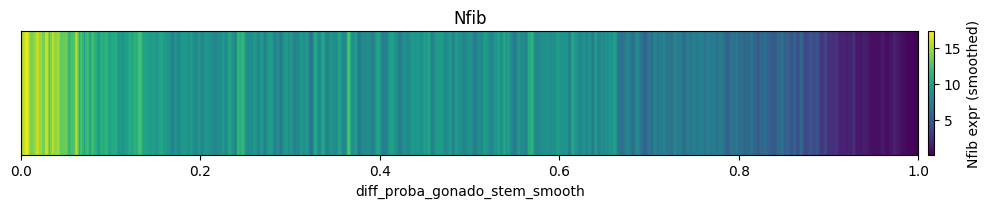

In [23]:
trajectory_strip(gonadotroph_trajectory_object, 'Nfib', 'diff_proba_gonado_stem_smooth')

In [ ]:
# Shows which samples are used in which bins 
pdata.obs["trajectory_gonado_smooth"]

In [28]:
# Generate a dataframe of the mean expression of each gene in each bin
X_pb = pdata.X
if hasattr(X_pb, 'toarray'):
    X_pb = X_pb.toarray()

bins = pdata.obs["trajectory_gonado_smooth"].astype(str).values
gene_names_pb = list(pdata.var_names)

# Mean expression per bin across pseudobulk samples (i.e. averaging over donors within each bin)
bin_labels = sorted(pd.unique(bins), key=lambda x: float(x))

bin_mean_expr_pb = {}
for b in bin_labels:
    mask = bins == b
    bin_mean_expr_pb[b] = X_pb[mask].mean(axis=0)

expr_df_pb = pd.DataFrame(bin_mean_expr_pb, index=gene_names_pb).T
# rows = bins, cols = genes

In [30]:
print(expr_df_pb)

   0610005C13Rik  0610006L08Rik  0610009E02Rik  0610009L18Rik  0610012D04Rik  \
0       1.038408       0.031054       2.911668       2.519325       0.007982   
1       1.457518       0.000000       2.436044       2.723998       0.000000   
2       0.469011       0.261797       2.606487       2.552087       0.000000   
3       0.399933       0.079612       2.166826       2.262082       0.013845   
4       0.913903       0.429478       1.861736       2.599365       0.000000   
5       1.519001       0.098694       2.511531       2.531024       0.015803   
6       1.107707       0.000000       2.670233       2.573068       0.080033   

   0610025J13Rik  0610030E20Rik  0610031O16Rik  0610033M10Rik  0610038B21Rik  \
0       1.212218       3.401303       0.008519       0.189555       0.463833   
1       0.573407       3.301190       0.000000       0.000000       0.659370   
2       0.548275       3.459763       0.000000       0.615919       0.268810   
3       1.353442       3.785369       0

In [31]:
# Filter to keep just the res_sig genes 
variable_genes = set(res_sig['gene'])
expr_df_pb_filtered = expr_df_pb.loc[:, expr_df_pb.columns.isin(variable_genes)]

In [38]:
print(expr_df_pb_filtered)

   0610040F04Rik  1110006O24Rik  1190005I06Rik  1300014J16Rik  1500002C15Rik  \
0       2.288639       1.222902       1.254842       1.804861       1.024354   
1       1.847175       0.589595       1.833210       2.070165       0.465657   
2       1.299044       1.306783       0.379028       1.643070       0.646587   
3       0.531181       0.409109       0.221643       1.174378       1.121951   
4       0.257652       1.455196       0.966222       0.524198       3.015001   
5       1.558228       1.863287       0.828182       1.185010       1.864152   
6       2.142114       1.842255       1.336879       1.163714       1.385460   

   1500009L16Rik  1500026H17Rik  1500035N22Rik  1600002D24Rik  1700001G11Rik  \
0       1.974952       1.577688       1.600803       2.308250       0.707440   
1       1.828289       1.423387       1.004336       2.458122       0.404974   
2       1.991023       1.159058       1.500938       2.001319       0.583015   
3       1.160470       1.026925       0

In [39]:
expr_df_pb_filtered.to_csv("/scratch/prj/stem_cells_pituitary/Georgia/RNAseq_data/expr_df_pb_filtered.csv")

In [69]:
res_sig.to_csv("/scratch/prj/stem_cells_pituitary/Georgia/RNAseq_data/res_sig_SC_Gonado_bins.csv", index=False)

#### **Extract gene expression dataframe**

In [9]:
adata.var_names

Index(['0610005C13Rik', '0610006L08Rik', '0610009E02Rik', '0610009L18Rik',
       '0610012D04Rik', '0610025J13Rik', '0610030E20Rik', '0610031O16Rik',
       '0610033M10Rik', '0610038B21Rik',
       ...
       'mt-Co2', 'mt-Co3', 'mt-Cytb', 'mt-Nd1', 'mt-Nd2', 'mt-Nd3', 'mt-Nd4',
       'mt-Nd4l', 'mt-Nd5', 'mt-Nd6'],
      dtype='object', length=31753)

In [10]:
pou_genes = [g for g in adata.var_names if g.startswith('Pou')]
print(pou_genes)

cell_types_ordered = ['Lactotrophs', 'Somatotrophs', 'Thyrotrophs', 'Melanotrophs', 'Corticotrophs', 'Gonadotrophs']

['Pou1f1', 'Pou2af1', 'Pou2af2', 'Pou2af3', 'Pou2f1', 'Pou2f2', 'Pou2f3', 'Pou3f1', 'Pou3f2', 'Pou3f3', 'Pou3f4', 'Pou4f1', 'Pou4f2', 'Pou4f3', 'Pou5f1', 'Pou5f2', 'Pou6f1', 'Pou6f2']


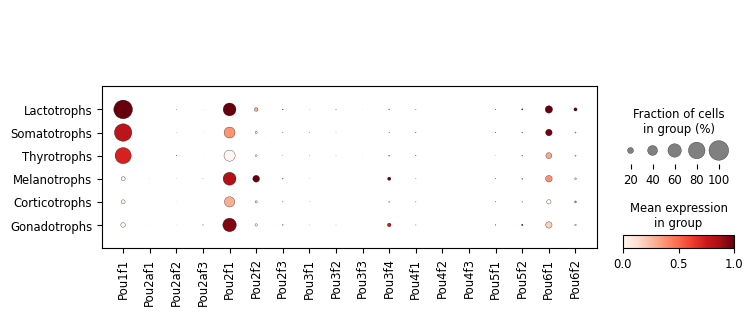

In [20]:
sc.pl.dotplot(
    adata[adata.obs['cell_type_final'].isin(cell_types_ordered)],
    var_names=pou_genes,
    groupby='cell_type_final',
    categories_order=cell_types_ordered,
    standard_scale='var',
    show=True
)

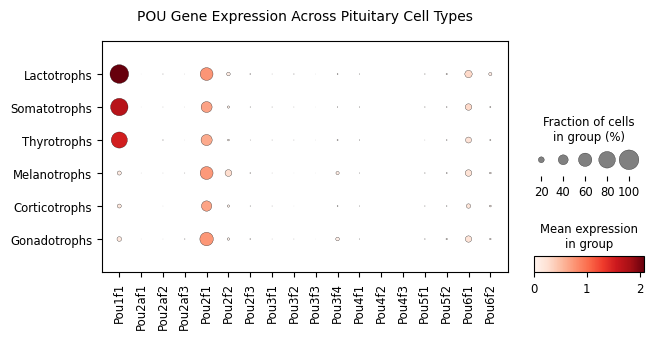

In [49]:
dp = sc.pl.dotplot(
    adata[adata.obs['cell_type_final'].isin(cell_types_ordered)],
    var_names=pou_genes,
    groupby='cell_type_final',
    categories_order=cell_types_ordered,
    standard_scale=None,
    figsize=(7,3.0),
    show=False,
    return_fig=True
)

ax = dp.get_axes()['mainplot_ax']
ax.set_title('POU Gene Expression Across Pituitary Cell Types', fontsize=10, pad=15)

plt.savefig(
    '/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/plots/footprints/individual/pou_gene_expression.svg',
    bbox_inches='tight', dpi=300)

In [13]:
# Pull Sox2 and Sox15 data from dataframe
sox_genes = [g for g in adata.var_names if g in ['Sox2', 'Sox15']]
print(sox_genes)

#cell_types_ordered = ['Lactotrophs', 'Somatotrophs', 'Thyrotrophs', 'Melanotrophs', 'Corticotrophs', 'Gonadotrophs']
cell_types_ordered = [ 'Stem_cells', 'Lactotrophs', 'Somatotrophs', 'Thyrotrophs', 'Melanotrophs', 'Corticotrophs', 'Gonadotrophs']


['Sox15', 'Sox2']


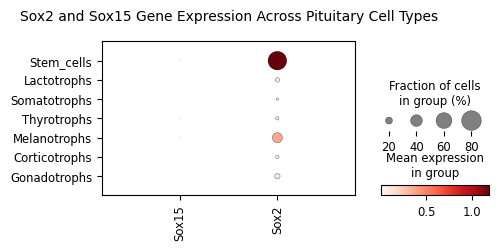

In [18]:
dp = sc.pl.dotplot(
    adata[adata.obs['cell_type_final'].isin(cell_types_ordered)],
    var_names=sox_genes,
    groupby='cell_type_final',
    categories_order=cell_types_ordered,
    standard_scale=None,
    figsize=(5,2.0),
    show=False,
    return_fig=True
)

ax = dp.get_axes()['mainplot_ax']
ax.set_title('Sox2 and Sox15 Gene Expression Across Pituitary Cell Types', fontsize=10, pad=15)

plt.savefig(
    '/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/plots/footprints/individual/sox_gene_expression.svg',
    bbox_inches='tight', dpi=300)

#### **Filter TFs for Stem Cell gene expression**

In [11]:
# Pull only stem cell data from the dataframe
stem_cells_adata = adata[adata.obs["cell_type_final"] == "Stem_cells"]

In [16]:
# Calculate the median expression for each gene
# (We handle sparse matrices safely by converting the result to a dense array)
if isinstance(stem_cells_adata.X, np.ndarray):
    median_expression = np.median(stem_cells_adata.X, axis=0)
else:
    # If it's a sparse matrix (e.g., csr_matrix), we convert to dense to compute median safely
    median_expression = np.median(stem_cells_adata.X.toarray(), axis=0)

# Create the small DataFrame
df_stem_medians = pd.DataFrame(
    {"median_expression": median_expression}, index=adata.var_names
)

# Preview the result
df_stem_medians

,median_expression
0610005C13Rik,0.000000
0610006L08Rik,0.000000
0610009E02Rik,0.000000
0610009L18Rik,0.000000
0610012D04Rik,0.000000
...,...
mt-Nd3,2.844643
mt-Nd4,3.263569
mt-Nd4l,1.623995
mt-Nd5,2.364391


In [23]:
# Load JASPAR TF data in
jaspar_2026 = "/scratch/prj/stem_cells_pituitary/Georgia/genome/JASPAR_CORE_2026_non-redundant.meme"
id_to_motif = {}
with open(jaspar_2026, 'r') as file:
    for line in file:
        if line.startswith("MOTIF"):
            parts = line.split()
            if len(parts) >= 3:
                id_to_motif[parts[1]] = parts[2]
jaspar_tfs = {symbol.upper() for symbol in id_to_motif.values()}

# Filter first just for TFs
df_stem_tfs = df_stem_medians[
    df_stem_medians.index.str.upper().isin(jaspar_tfs)
]
#df_stem_tfs

# Then filter for median expression >0.4
df_stem_tfs_filtered = df_stem_tfs[df_stem_tfs["median_expression"] > 0.4]

print(f"Filtered down to {df_stem_tfs_filtered.shape[0]} TFs with mean expression > 0.4")
df_stem_tfs_filtered

Filtered down to 74 TFs with mean expression > 0.4


,median_expression
Ar,0.938418
Atf2,0.988604
Bach2,0.853479
Bcl11a,0.840200
Creb1,0.840574
...,...
Tcf7l2,1.297202
Tead1,1.744093
Trps1,1.576794
Vezf1,0.952567


In [24]:
# Save dataframe
df_stem_tfs_filtered.to_csv("/scratch/prj/stem_cells_pituitary/Georgia/RNAseq_data/stem_cells_neonatal_TF_median_expr.csv")